In [1]:
# Load relevant libraries
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv("/content/flipkart.csv")

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display first few rows
print("First 5 rows of the dataset:")
print(data.head())

# Display dataset information
print("\nDataset Information:")
print(data.info())

# Display dataset shape
print("\nDataset Shape:", data.shape)

First 5 rows of the dataset:
   Unnamed: 0                                       Product_name  \
0           0  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
1           1  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
2           2  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
3           3  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   
4           4  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   

                                              Review  Rating  
0  Best under 60k Great performanceI got it for a...       5  
1                                 Good perfomence...       5  
2  Great performance but usually it has also that...       5  
3           My wife is so happy and best product 👌🏻😘       5  
4  Light weight laptop with new amazing features,...       5  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------   

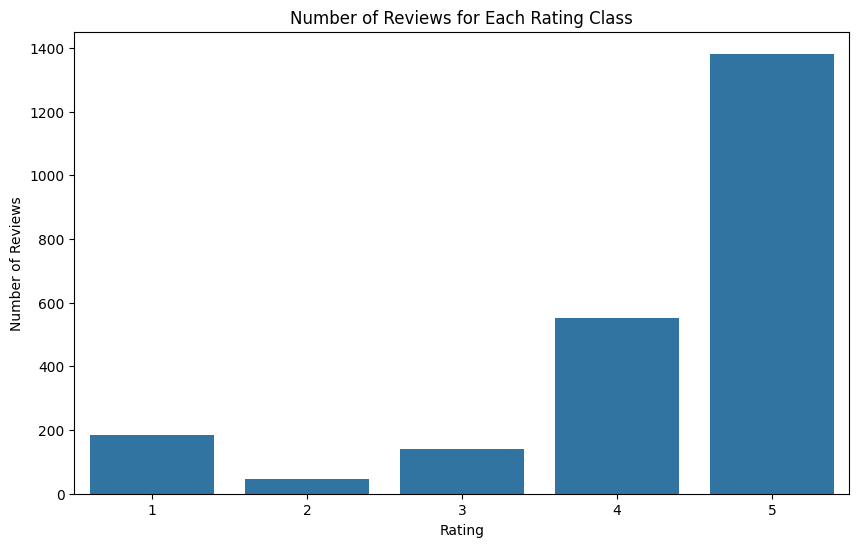

In [3]:
# Plotting the number of reviews for each rating class
plt.figure(figsize=(10, 6))
sns.countplot(x='Rating', data=data)
plt.title('Number of Reviews for Each Rating Class')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

In [4]:
# Check for missing values
missing_values = data.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)


Missing values in each column:
Unnamed: 0      0
Product_name    0
Review          0
Rating          0
dtype: int64


<ipython-input-5-1d64ae1cf211>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')


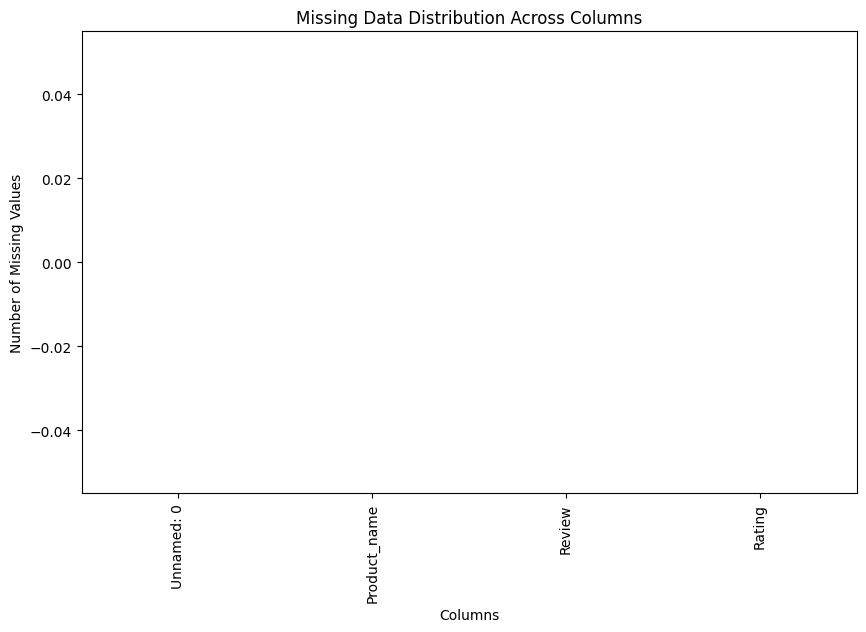

In [5]:
# Plot missing data distribution across columns
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Data Distribution Across Columns')
plt.xticks(rotation=90)
plt.show()

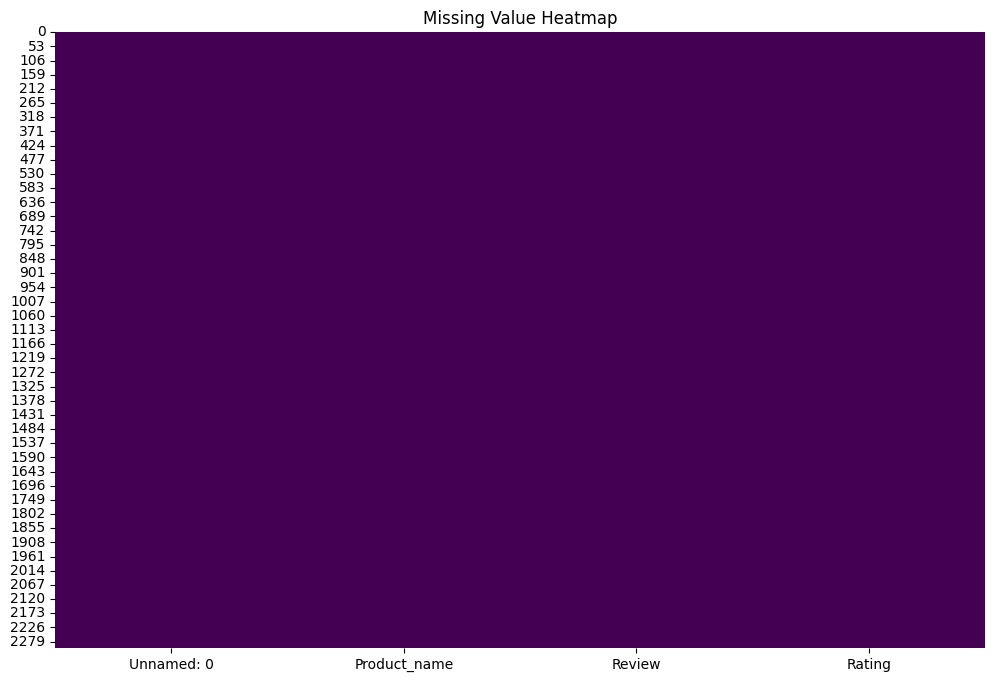

In [6]:
# Plot Missing Value Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

In [7]:
# Import necessary libraries for text preprocessing
import spacy
from spacy.cli import download

# Load SpaCy's English model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# Custom stopword list (preserving negations like "not" and "no")
from spacy.lang.en.stop_words import STOP_WORDS
negations = {"not", "no", "never", "none", "nobody", "nothing", "nowhere", "neither", "nor", "however", "hate", "terrible"}
custom_stopwords = STOP_WORDS - negations

# Define text preprocessing function
def text_preprocessing(text):
    # Process the text with SpaCy
    doc = nlp(text.lower())  # Convert to lowercase and process with SpaCy
    return ' '.join([
        token.lemma_ for token in doc
        if token.text not in custom_stopwords and token.is_alpha
    ])

# Apply preprocessing directly to the 'Review' column
data['Cleaned_Review'] = data['Review'].astype(str).apply(text_preprocessing)

# Display the cleaned reviews
print(data[['Review', 'Cleaned_Review']].head())

                                              Review  \
0  Best under 60k Great performanceI got it for a...   
1                                 Good perfomence...   
2  Great performance but usually it has also that...   
3           My wife is so happy and best product 👌🏻😘   
4  Light weight laptop with new amazing features,...   

                                      Cleaned_Review  
0  well great performancei get backup bit low tha...  
1                                    good perfomence  
2  great performance usually game laptop issue ba...  
3                            wife happy good product  
4  light weight laptop new amazing feature batter...  


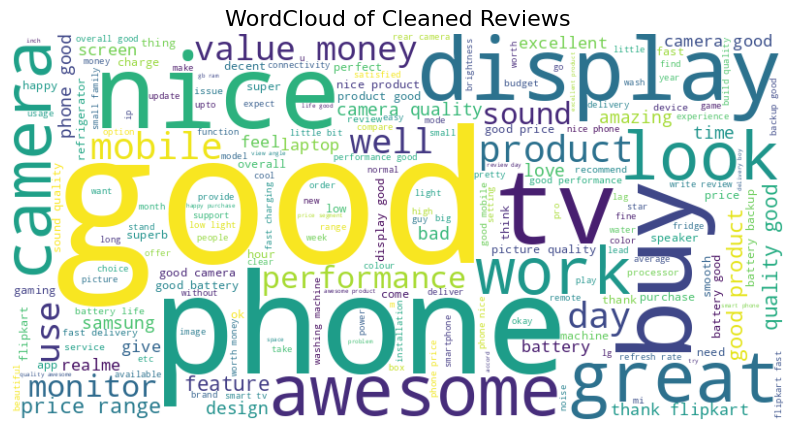

In [8]:
# Import necessary library for WordCloud
from wordcloud import WordCloud

# Generate a WordCloud for the 'Cleaned_Review' column
cleaned_text = " ".join(review for review in data['Cleaned_Review'])

# Create and display the WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(cleaned_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Cleaned Reviews", fontsize=16)
plt.show()

In [9]:
# Function to assign sentiment labels based on ratings
def get_sentiment_from_rating(rating):
    """
    Maps numerical ratings to sentiment labels:
    - 1, 2 -> Negative
    - 3 -> Neutral
    - 4, 5 -> Positive
    """
    if rating in [1, 2]:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    elif rating in [4, 5]:
        return "Positive"

# Apply the sentiment mapping to the 'Rating' column
data["Rating_Sentiment"] = data["Rating"].apply(get_sentiment_from_rating)

# Display the first 5 rows of the updated dataset
print("\nDataset with Rating-Based Sentiment:")
print(data.head())


Dataset with Rating-Based Sentiment:
   Unnamed: 0                                       Product_name  \
0           0  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
1           1  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
2           2  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
3           3  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   
4           4  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   

                                              Review  Rating  \
0  Best under 60k Great performanceI got it for a...       5   
1                                 Good perfomence...       5   
2  Great performance but usually it has also that...       5   
3           My wife is so happy and best product 👌🏻😘       5   
4  Light weight laptop with new amazing features,...       5   

                                      Cleaned_Review Rating_Sentiment  
0  well great performancei get backup bit low tha...         Positive  
1                       

<ipython-input-10-1a76f7cd84f4>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating_Sentiment', data=data, palette='viridis')


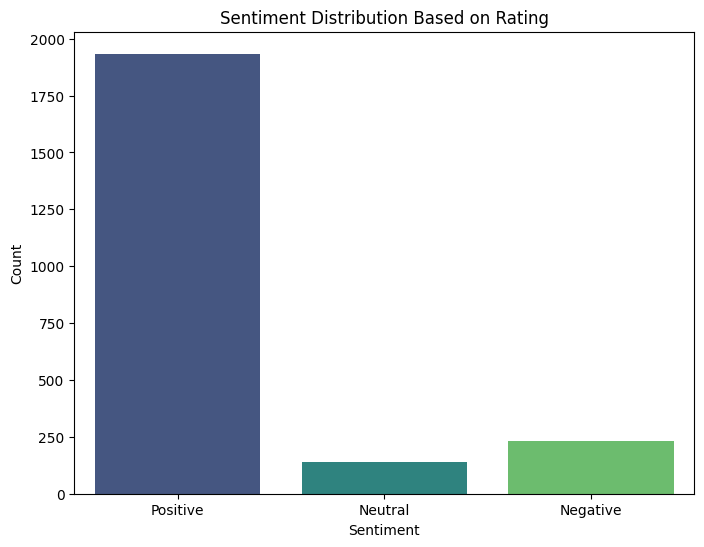

In [10]:
# Plot Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Rating_Sentiment', data=data, palette='viridis')
plt.title('Sentiment Distribution Based on Rating')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [11]:
# Import VADER for sentiment analysis
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download the VADER lexicon
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [12]:
# Initialize the VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Define a function to compute VADER sentiment scores
def analyze_sentiment_vader(text):
    """
    Analyze sentiment using VADER and return the sentiment label.
    """
    sentiment_scores = sia.polarity_scores(text)
    if sentiment_scores['compound'] >= 0.1:
        return "Positive"
    elif sentiment_scores['compound'] <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply VADER sentiment analysis to the 'Cleaned_Review' column
data['VADER_Sentiment'] = data['Cleaned_Review'].apply(analyze_sentiment_vader)

In [13]:
# Display the first few rows of the dataset with the new sentiment column
print("\nDataset with VADER Sentiment Analysis:")
print(data[['Cleaned_Review', 'VADER_Sentiment']].head())


Dataset with VADER Sentiment Analysis:
                                      Cleaned_Review VADER_Sentiment
0  well great performancei get backup bit low tha...        Positive
1                                    good perfomence        Positive
2  great performance usually game laptop issue ba...        Positive
3                            wife happy good product        Positive
4  light weight laptop new amazing feature batter...        Positive


<ipython-input-14-e6af266f62d3>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='VADER_Sentiment', data=data, palette='coolwarm')


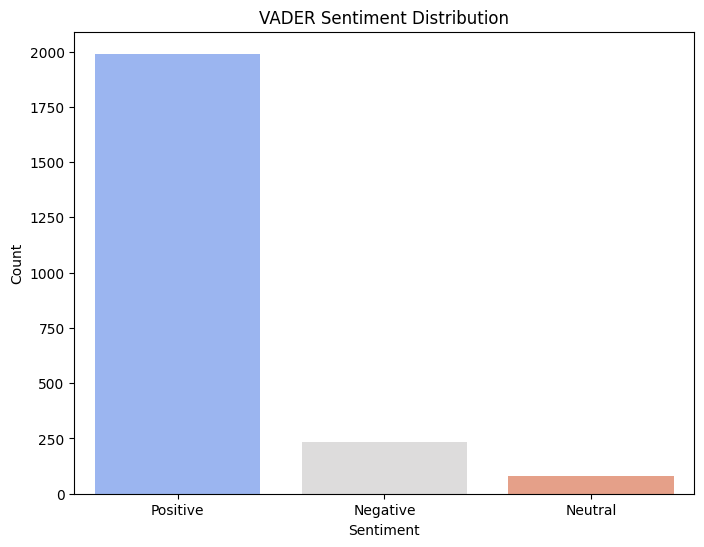

In [14]:
# Plot VADER Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='VADER_Sentiment', data=data, palette='coolwarm')
plt.title('VADER Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

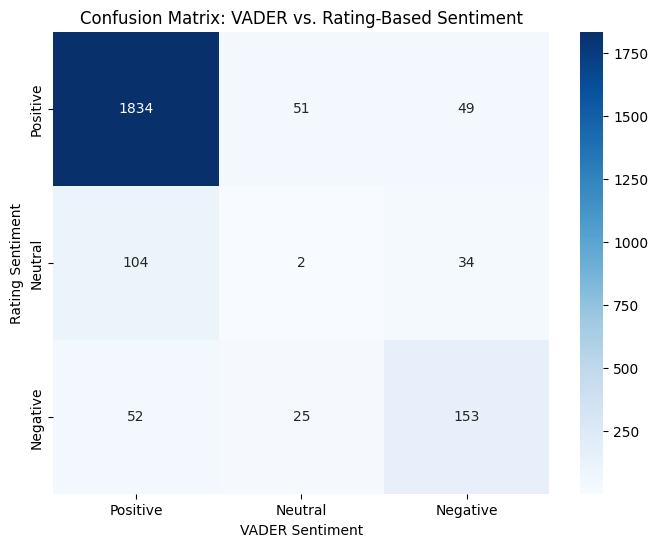

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
conf_matrix = confusion_matrix(data['Rating_Sentiment'], data['VADER_Sentiment'], labels=["Positive", "Neutral", "Negative"])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Positive", "Neutral", "Negative"], yticklabels=["Positive", "Neutral", "Negative"])
plt.title("Confusion Matrix: VADER vs. Rating-Based Sentiment")
plt.xlabel("VADER Sentiment")
plt.ylabel("Rating Sentiment")
plt.show()

In [16]:
print(data.columns)

Index(['Unnamed: 0', 'Product_name', 'Review', 'Rating', 'Cleaned_Review',
       'Rating_Sentiment', 'VADER_Sentiment'],
      dtype='object')


<ipython-input-17-f7d0abb21174>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=data, palette='pastel')


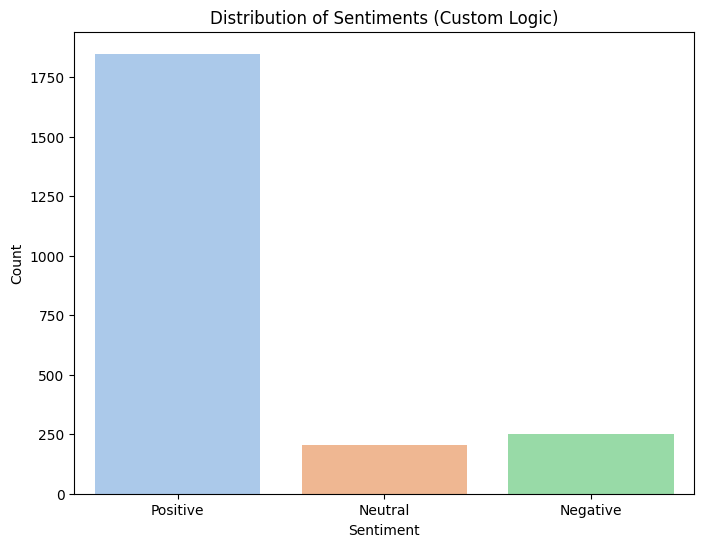

In [17]:
# Create the new "sentiment" column based on the given logic
data['Sentiment'] = data.apply(
    lambda row: "Neutral" if row['Rating'] == 3 else (
        "Negative" if row['Rating'] == 1 else row['VADER_Sentiment']
    ), axis=1
)

# Plot the distribution of the new "Sentiment" column
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=data, palette='pastel')
plt.title('Distribution of Sentiments (Custom Logic)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [18]:
# Display the first few rows to verify the new column
data[['Rating', 'VADER_Sentiment', 'Sentiment']].head(50)

,Rating,VADER_Sentiment,Sentiment
0,5,Positive,Positive
1,5,Positive,Positive
2,5,Positive,Positive
3,5,Positive,Positive
4,5,Positive,Positive
5,5,Positive,Positive
6,5,Positive,Positive
7,4,Positive,Positive
8,5,Positive,Positive
9,3,Positive,Neutral


In [19]:
# Retain only the relevant columns
cleaned_data = data[['Product_name', 'Cleaned_Review', 'Sentiment']]

# Display the first few rows
print(cleaned_data.head())

                                        Product_name  \
0  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
1  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
2  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
3  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   
4  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   

                                      Cleaned_Review Sentiment  
0  well great performancei get backup bit low tha...  Positive  
1                                    good perfomence  Positive  
2  great performance usually game laptop issue ba...  Positive  
3                            wife happy good product  Positive  
4  light weight laptop new amazing feature batter...  Positive  


In [20]:
# Encode the sentiment labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
cleaned_data['Sentiment_Encoded'] = label_encoder.fit_transform(cleaned_data['Sentiment'])

# Display the first few rows
print(cleaned_data.head())

                                        Product_name  \
0  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
1  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
2  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
3  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   
4  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   

                                      Cleaned_Review Sentiment  \
0  well great performancei get backup bit low tha...  Positive   
1                                    good perfomence  Positive   
2  great performance usually game laptop issue ba...  Positive   
3                            wife happy good product  Positive   
4  light weight laptop new amazing feature batter...  Positive   

   Sentiment_Encoded  
0                  2  
1                  2  
2                  2  
3                  2  
4                  2  


<ipython-input-20-fcbee8598808>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['Sentiment_Encoded'] = label_encoder.fit_transform(cleaned_data['Sentiment'])


In [21]:
# Display the mapping of sentiment labels to encoded classes
print("Sentiment Encoding Mapping:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Sentiment Encoding Mapping:
{'Negative': 0, 'Neutral': 1, 'Positive': 2}


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Perform TF-IDF Vectorization on the Cleaned_Review column
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
cleaned_data_tfidf = tfidf_vectorizer.fit_transform(cleaned_data['Cleaned_Review'])

In [23]:
# Print the TF-IDF Feature Matrix Shape
print("\nTF-IDF Feature Matrix Shape:", cleaned_data_tfidf.shape)
# Display the first few rows
print(cleaned_data.head())


TF-IDF Feature Matrix Shape: (2304, 3051)
                                        Product_name  \
0  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
1  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
2  Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...   
3  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   
4  DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...   

                                      Cleaned_Review Sentiment  \
0  well great performancei get backup bit low tha...  Positive   
1                                    good perfomence  Positive   
2  great performance usually game laptop issue ba...  Positive   
3                            wife happy good product  Positive   
4  light weight laptop new amazing feature batter...  Positive   

   Sentiment_Encoded  
0                  2  
1                  2  
2                  2  
3                  2  
4                  2  


In [24]:
from sklearn.model_selection import train_test_split

# Train-Test Split
X = cleaned_data_tfidf
y = cleaned_data['Sentiment_Encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTrain and Test Split Completed:")
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)


Train and Test Split Completed:
Training Set Shape: (1843, 3051)
Testing Set Shape: (461, 3051)


In [25]:
from sklearn.svm import SVC

# Train a Support Vector Machine
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [26]:
# Predict on the test set
y_pred = svm_classifier.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nSVM Classifier Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


SVM Classifier Accuracy: 0.9240780911062907
Precision: 0.9186614209145655
Recall: 0.9240780911062907
F1 Score: 0.9115417211553013

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.85      0.87        53
     Neutral       0.82      0.28      0.42        32
    Positive       0.93      0.99      0.96       376

    accuracy                           0.92       461
   macro avg       0.88      0.71      0.75       461
weighted avg       0.92      0.92      0.91       461



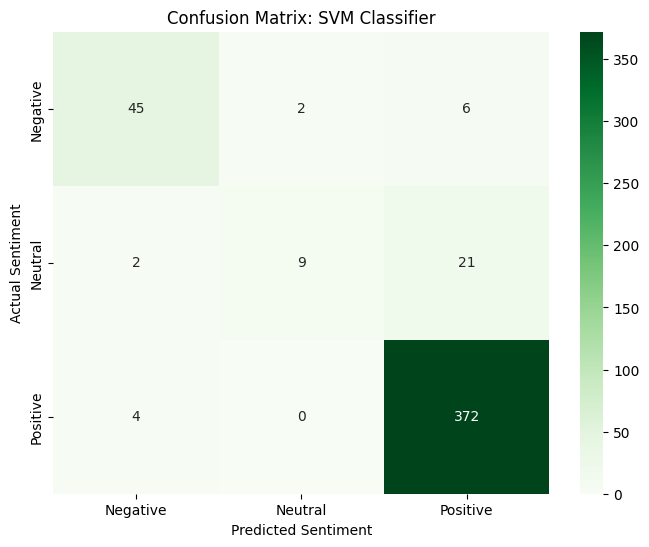

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate and plot the confusion matrix for SVM
svm_conf_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
plt.figure(figsize=(8, 6))
sns.heatmap(svm_conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix: SVM Classifier")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

In [29]:
from sklearn.linear_model import LogisticRegression

# Train a Logistic Regression model
logreg_classifier = LogisticRegression(random_state=42, max_iter=1000)
logreg_classifier.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [30]:
# Predict on the test set
y_pred_logreg = logreg_classifier.predict(X_test)

In [31]:
# Evaluate the Logistic Regression model
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg, average='weighted')
recall_logreg = recall_score(y_test, y_pred_logreg, average='weighted')
f1_logreg = f1_score(y_test, y_pred_logreg, average='weighted')

print("\nLogistic Regression Classifier Accuracy:", accuracy_logreg)
print("Precision:", precision_logreg)
print("Recall:", recall_logreg)
print("F1 Score:", f1_logreg)

print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_logreg, target_names=label_encoder.classes_))


Logistic Regression Classifier Accuracy: 0.9002169197396963
Precision: 0.9075875619689113
Recall: 0.9002169197396963
F1 Score: 0.8817906439895921

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

    Negative       0.94      0.60      0.74        53
     Neutral       1.00      0.25      0.40        32
    Positive       0.89      1.00      0.94       376

    accuracy                           0.90       461
   macro avg       0.95      0.62      0.69       461
weighted avg       0.91      0.90      0.88       461



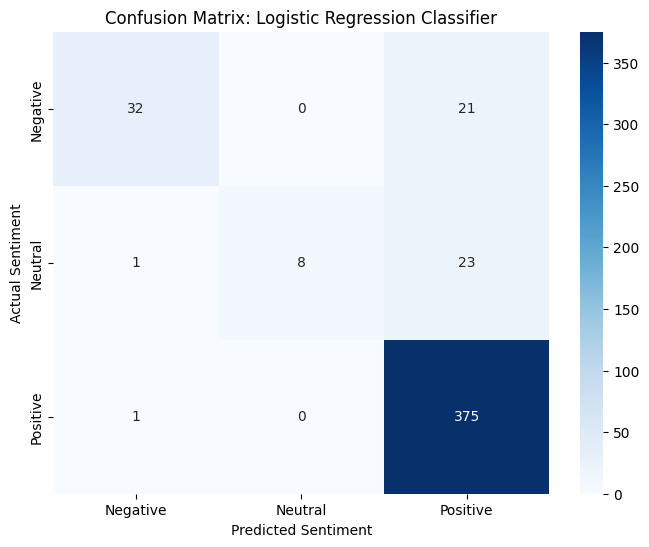

In [32]:
# Generate and plot the confusion matrix for Logistic Regression
logreg_conf_matrix = confusion_matrix(y_test, y_pred_logreg, labels=[0, 1, 2])
plt.figure(figsize=(8, 6))
sns.heatmap(logreg_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix: Logistic Regression Classifier")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

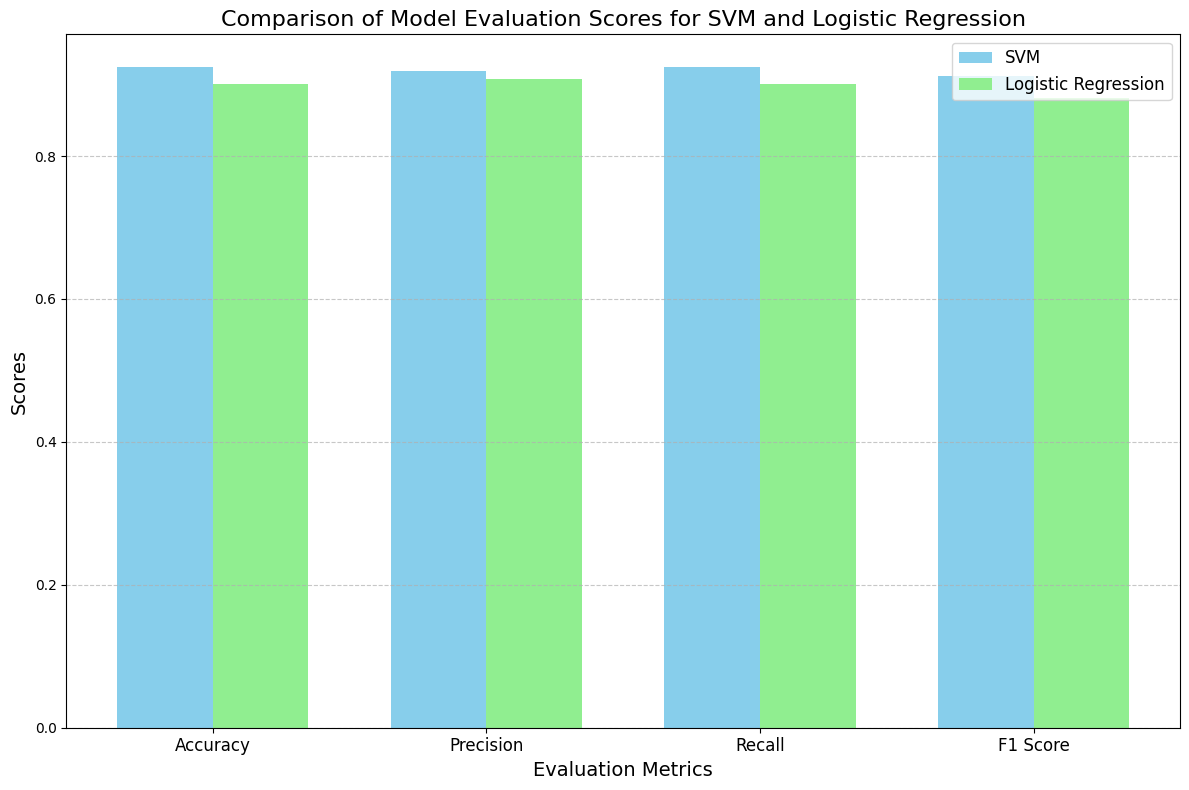

In [33]:
# Evaluation metrics for both models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
svm_scores = [accuracy, precision, recall, f1]
logreg_scores = [accuracy_logreg, precision_logreg, recall_logreg, f1_logreg]

# Number of metrics
x = np.arange(len(metrics))

# Width of the bars
width = 0.35

# Create the plot
plt.figure(figsize=(12, 8))

# Plot SVM scores
plt.bar(x - width/2, svm_scores, width, label='SVM', color='skyblue')

# Plot Logistic Regression scores
plt.bar(x + width/2, logreg_scores, width, label='Logistic Regression', color='lightgreen')

# Add labels and title
plt.xlabel('Evaluation Metrics', fontsize=14)
plt.ylabel('Scores', fontsize=14)
plt.title('Comparison of Model Evaluation Scores for SVM and Logistic Regression', fontsize=16)

# Set the position and labels of the x-ticks
plt.xticks(x, metrics, fontsize=12)

# Add a legend
plt.legend(fontsize=12)

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [45]:
# Example new reviews
new_reviews = [
    "one time buy",
    "the staff behaved average",
    "i am happy with the purchase"
]

# Preprocess the new reviews
new_cleaned_reviews = pd.Series(new_reviews).apply(text_preprocessing)

# Vectorize the new reviews
new_features = tfidf_vectorizer.transform(new_cleaned_reviews)

# Predict using SVM
svm_new_predictions = svm_classifier.predict(new_features)
svm_pred_sentiments = label_encoder.inverse_transform(svm_new_predictions)

# Predict using Logistic Regression
logreg_new_predictions = logreg_classifier.predict(new_features)
logreg_pred_sentiments = label_encoder.inverse_transform(logreg_new_predictions)

# Display predictions
for i, review in enumerate(new_reviews):
    print(f"\nReview: {review}")
    print(f"SVM Predicted Sentiment: {svm_pred_sentiments[i]}")
    print(f"Logistic Regression Predicted Sentiment: {logreg_pred_sentiments[i]}")


Review: one time buy
SVM Predicted Sentiment: Negative
Logistic Regression Predicted Sentiment: Negative

Review: the staff behaved average
SVM Predicted Sentiment: Neutral
Logistic Regression Predicted Sentiment: Positive

Review: i am happy with the purchase
SVM Predicted Sentiment: Positive
Logistic Regression Predicted Sentiment: Positive
